In [1]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix,make_scorer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
testsize=0.2
file = r"/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9_2.xlsx"
f1 = make_scorer(f1_score, average="macro")
parameters = {'n_estimators' : [i for i in range(0,100,5)], 'max_depth': [i for i in range(0,100,10)],'criterion': ['gini','entropy','log_loss'],
              'max_features': np.arange(1,11,1)}
model_test = RandomForestClassifier()
model = GridSearchCV(model_test, param_grid=parameters,verbose=3,scoring=f1,cv=5,n_jobs=6)
# model = RandomForestClassifier(max_depth=None,n_estimators=100,max_features=None)

In [3]:
iteration = []
f1 = []
re = []
pr = []
for i in range(1,301):
    iteration.append(i)
    # model = RandomForestClassifier(max_depth=11,n_estimators=i,max_features=None)
    data =pd.read_excel(file,header=0)
    data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
    
    # scaler = MinMaxScaler(feature_range=(-1,1))
    # scaler = MinMaxScaler()
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data.iloc[:,:-2])
    
    labeler = LabelEncoder()
    target = labeler.fit_transform(data['Mineral'])
    
    minerals = len(labeler.classes_)+1
    acc_table = np.zeros((minerals,12))
    recall_table = np.zeros((minerals,12))
    precision_table = np.zeros((minerals,12))
    
    #%%
    splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
    split, split1 = splitter.split(data_scaled, target)
    train_data = data_scaled[split1[0],:]
    train_label = target[split1[0]]
    test_data = data_scaled[split1[1],:]
    test_label = target[split1[1]]
    
    print(f"Testing for raw input data {i}\n")
    
    model.fit(train_data, train_label)
    pred_label = model.predict(test_data)
    a = round(f1_score(test_label, pred_label, average="macro"),4)*100
    r = round(recall_score(test_label, pred_label, average="macro"),4)*100
    p = round(precision_score(test_label, pred_label, average="macro"),4)*100
    # acc_table[0,0] = a
    # precision_table[0,0] = p
    # recall_table[0,0] = r
    # print(round(a,2))
    f1.append(a)
    re.append(r)
    pr.append(p)
    # cm_raw = confusion_matrix(test_label, pred_label,normalize='pred')
    # cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
    # plt.rc('font',size=10,family='serif')
    # plt.figure(figsize=(10,10),dpi=600)
    # sns.heatmap(cm_raw, annot=False,cmap="viridis",fmt='.2f',linewidths=0.2,linecolor='black')
    # # plt.axes(
    
    # for i in range(0,minerals-1):
    #     test_data1 = test_data[test_label==i]
    #     test_label1 = test_label[test_label==i]
    #     pred_label1 = model.predict(test_data1)
    #     a = round(f1_score(test_label1, pred_label1, average="micro"),4)*100
    #     r = round(recall_score(test_label1, pred_label1, average="micro"),4)*100
    #     p = round(precision_score(test_label1, pred_label1, average="micro"),4)*100
    #     acc_table[i+1,0] = a
    #     precision_table[i+1,0] = p
    #     recall_table[i+1,0] = r
    #     name = labeler.inverse_transform([i])[0]
    #     print(f"{i} {name}: accuracy: {a}")
    
    # for i in range(0,m):
    #     test_data1 = data_scaled[target==i]
    #     test_label1 = target[target==i]
    #     pred_label1 = model.predict(test_data1)
    #     a = round(f1_score(test_label1, pred_label1, average="micro"),4)*100
    #     acc_table[i+1,0] = a
    #     name = labeler.inverse_transform([i])[0]
    #     print(f"{name}: accuracy: {a}")
    
    # pred_label = model.predict(data_scaled)
    # test_data_df = data.copy()
    # test_data_df['Pred'] = labeler.inverse_transform(pred_label)
    # test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]


Testing for raw input data 1

Testing for raw input data 2

Testing for raw input data 3

Testing for raw input data 4

Testing for raw input data 5

Testing for raw input data 6

Testing for raw input data 7

Testing for raw input data 8

Testing for raw input data 9

Testing for raw input data 10

Testing for raw input data 11

Testing for raw input data 12

Testing for raw input data 13

Testing for raw input data 14

Testing for raw input data 15

Testing for raw input data 16

Testing for raw input data 17

Testing for raw input data 18

Testing for raw input data 19

Testing for raw input data 20

Testing for raw input data 21

Testing for raw input data 22

Testing for raw input data 23

Testing for raw input data 24

Testing for raw input data 25

Testing for raw input data 26

Testing for raw input data 27

Testing for raw input data 28

Testing for raw input data 29

Testing for raw input data 30

Testing for raw input data 31

Testing for raw input data 32

Testing for raw i

[5.52,
 9.62,
 16.31,
 34.94,
 37.56,
 52.65,
 68.51,
 86.07000000000001,
 92.10000000000001,
 97.92,
 99.74,
 99.79,
 99.69,
 99.81,
 99.7,
 99.68,
 99.59,
 99.61,
 99.78,
 99.78,
 99.63,
 99.71,
 99.55000000000001,
 99.82,
 99.83999999999999,
 99.81,
 99.69,
 99.71,
 99.79,
 99.74,
 99.78,
 99.77000000000001,
 99.64,
 99.76,
 99.72,
 99.75,
 99.78,
 99.7,
 99.62,
 99.74,
 99.79,
 99.77000000000001,
 99.58,
 99.65,
 99.68,
 99.72,
 99.7,
 99.83999999999999,
 99.76,
 99.69,
 99.77000000000001,
 99.74,
 99.78,
 99.72999999999999,
 99.81,
 99.77000000000001,
 99.79,
 99.58,
 99.78,
 99.67,
 99.79,
 99.76,
 99.85000000000001,
 99.77000000000001,
 99.56,
 99.65,
 99.63,
 99.72,
 99.57000000000001,
 99.59,
 99.64,
 99.62,
 99.66000000000001,
 99.61,
 99.64,
 99.53999999999999,
 99.75,
 99.62,
 99.79,
 99.77000000000001,
 99.72999999999999,
 99.69,
 99.64,
 99.63,
 99.75,
 99.77000000000001,
 99.71,
 99.77000000000001,
 99.82,
 99.83999999999999,
 99.68,
 99.65,
 99.77000000000001,
 99.8,
 9

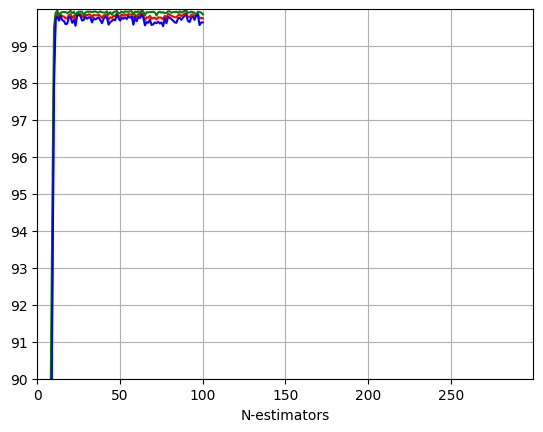

In [11]:
plt.plot(iteration,f1,'r-',iteration,re,'g-',iteration,pr,'b-')
plt.xlabel("N-estimators")
plt.xticks(np.arange(0,300,50))
plt.yticks(np.arange(90,100,1))
plt.ylim(90,100)
plt.xlim(000,300)
plt.grid(axis='both')
pr

In [5]:
iteration = []
f1 = []
re = []
pr = []
for i in range(1,101):
    iteration.append(i)
    model = RandomForestClassifier(max_depth=i,n_estimators=1,max_features=None)
    data =pd.read_excel(file,header=0)
    data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
    
    # scaler = MinMaxScaler(feature_range=(-1,1))
    # scaler = MinMaxScaler()
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data.iloc[:,:-2])
    
    labeler = LabelEncoder()
    target = labeler.fit_transform(data['Mineral'])
    
    minerals = len(labeler.classes_)+1
    acc_table = np.zeros((minerals,12))
    recall_table = np.zeros((minerals,12))
    precision_table = np.zeros((minerals,12))
    
    #%%
    splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
    split, split1 = splitter.split(data_scaled, target)
    train_data = data_scaled[split1[0],:]
    train_label = target[split1[0]]
    test_data = data_scaled[split1[1],:]
    test_label = target[split1[1]]
    
    print(f"Testing for raw input data {i}\n")
    
    model.fit(train_data, train_label)
    pred_label = model.predict(test_data)
    a = round(f1_score(test_label, pred_label, average="macro"),4)*100
    r = round(recall_score(test_label, pred_label, average="macro"),4)*100
    p = round(precision_score(test_label, pred_label, average="macro"),4)*100
    # acc_table[0,0] = a
    # precision_table[0,0] = p
    # recall_table[0,0] = r
    # print(round(a,2))
    f1.append(a)
    re.append(r)
    pr.append(p)
    # cm_raw = confusion_matrix(test_label, pred_label,normalize='pred')
    # cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
    # plt.rc('font',size=10,family='serif')
    # plt.figure(figsize=(10,10),dpi=600)
    # sns.heatmap(cm_raw, annot=False,cmap="viridis",fmt='.2f',linewidths=0.2,linecolor='black')
    # # plt.axes(
    
    # for i in range(0,minerals-1):
    #     test_data1 = test_data[test_label==i]
    #     test_label1 = test_label[test_label==i]
    #     pred_label1 = model.predict(test_data1)
    #     a = round(f1_score(test_label1, pred_label1, average="micro"),4)*100
    #     r = round(recall_score(test_label1, pred_label1, average="micro"),4)*100
    #     p = round(precision_score(test_label1, pred_label1, average="micro"),4)*100
    #     acc_table[i+1,0] = a
    #     precision_table[i+1,0] = p
    #     recall_table[i+1,0] = r
    #     name = labeler.inverse_transform([i])[0]
    #     print(f"{i} {name}: accuracy: {a}")
    
    # for i in range(0,m):
    #     test_data1 = data_scaled[target==i]
    #     test_label1 = target[target==i]
    #     pred_label1 = model.predict(test_data1)
    #     a = round(f1_score(test_label1, pred_label1, average="micro"),4)*100
    #     acc_table[i+1,0] = a
    #     name = labeler.inverse_transform([i])[0]
    #     print(f"{name}: accuracy: {a}")
    
    # pred_label = model.predict(data_scaled)
    # test_data_df = data.copy()
    # test_data_df['Pred'] = labeler.inverse_transform(pred_label)
    # test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]


Testing for raw input data 1



/Users/aditya/Documents/python_geology/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Testing for raw input data 2



/Users/aditya/Documents/python_geology/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Testing for raw input data 3



...

Testing for raw input data 8



/Users/aditya/Documents/python_geology/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Testing for raw input data 9



/Users/aditya/Documents/python_geology/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Testing for raw input data 10

Testing for raw input data 11

Testing for raw input data 12

Testing for raw input data 13

Testing for raw input data 14

Testing for raw input data 15

Testing for raw input data 16

Testing for raw input data 17

Testing for raw input data 18

Testing for raw input data 19

Testing for raw input data 20

Testing for raw input data 21

Testing for raw input data 22

Testing for raw input data 23

Testing for raw input data 24

Testing for raw input data 25

Testing for raw input data 26

Testing for raw input data 27

Testing for raw input data 28

Testing for raw input data 29

Testing for raw input data 30

Testing for raw input data 31

Testing for raw input data 32

Testing for raw input data 33

Testing for raw input data 34

Testing for raw input data 35

Testing for raw input data 36

Testing for raw input data 37

Testing for raw input data 38

Testing for raw input data 39

Testing for raw input data 40

Testing for raw input data 41

Testing 

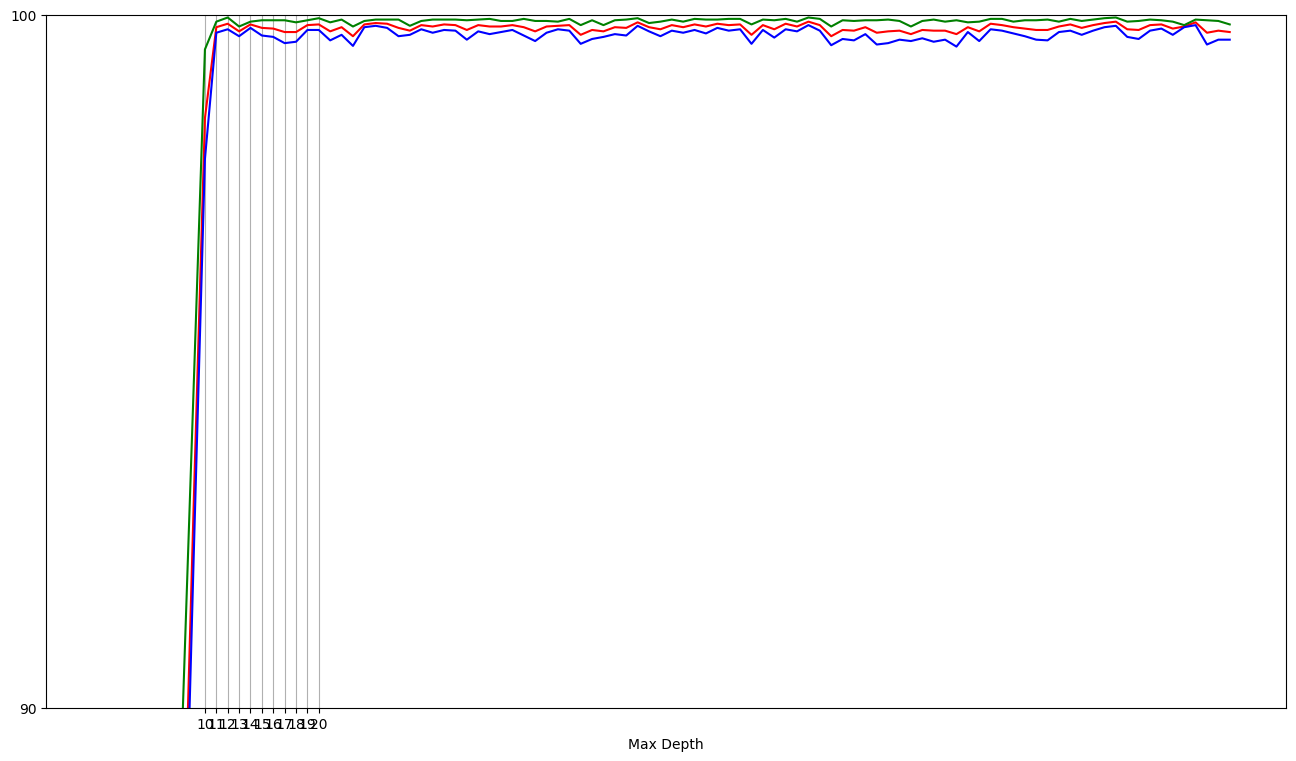

In [6]:
plt.figure(figsize=(16,9))
plt.plot(iteration,f1,'r-',iteration,re,'g-',iteration,pr,'b-')
plt.xlabel("Max Depth")
plt.xticks(np.arange(10,21,1))
plt.yticks(np.arange(90,101,10))
plt.ylim(90,100)
plt.grid(axis='x')